# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install
Python 3.6 (Anaconda3-5.2.0-Windows-x86_64)

In [ ]:
!pip uninstall --yes PT3S
!pip install PT3S

## PT3S Imports

In [ ]:
%pwd

In [1]:
# currentWorkingDirectory should be after Kernel (Re-)Start the notebookDir 
# in this case PT3SSourcecodeDir (the Dir with PT3S' __init__.py and PT3S.ipynb (this notebook))

# PT3S-Imports:
# only if
# !pip install -e .
# is active 
# then _before the PT3S Imports the currentWorkingDirectory _has to be changed to .. PT3SSourcecodeDir  
%cd -q ..
from PT3S import Mx,Xm,Rm
%cd -q PT3S 
# if !pip install -e . is active the cd-Change has no effect  

# Imports

In [2]:
import unittest
import doctest

# Doctest

In [ ]:
dtFinder=doctest.DocTestFinder(verbose=True)

In [ ]:
dTests=dtFinder.find(Mx,globs={'testDir':'testdata'}) # returns a list of DocTests 

In [ ]:
dtRunner=doctest.DocTestRunner(verbose=False) 
dtRunner.run(dTests[0])

In [ ]:
len(dTests)
print(dTests)

In [ ]:
dir(dTests)

In [ ]:
dir(dTests[1])

In [ ]:
dTests[0].docstring

In [ ]:
dTests[0].globs

# Test Mx

In [5]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Mx))#,globs={'testDir':'testdata'}))  

.
----------------------------------------------------------------------
Ran 1 test in 3.195s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

# Test Xm

In [6]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Xm))  

.
----------------------------------------------------------------------
Ran 1 test in 13.135s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

# Test Rm

.
----------------------------------------------------------------------
Ran 1 test in 3.316s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

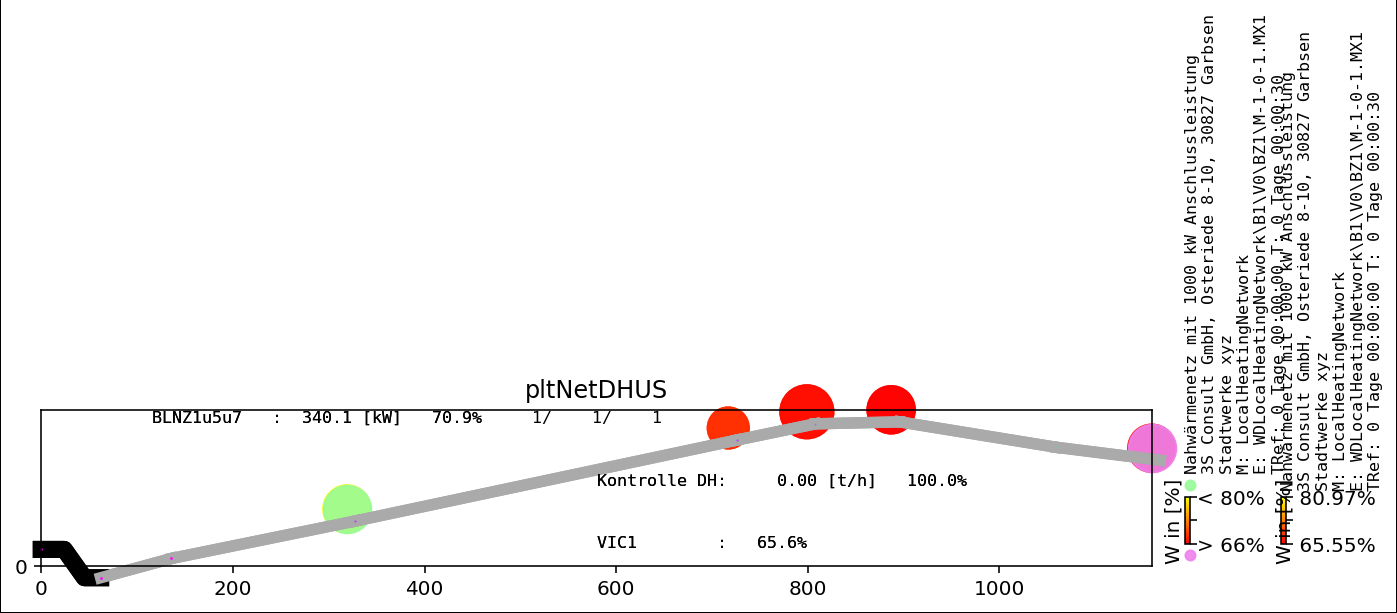

In [7]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Rm))  

# Rm Plot Beispiele

## Vorbereitung

In [8]:
# ---
# Imports
# ---
import logging
logger = logging.getLogger('PT3S')  
import os
import pandas as pd
import matplotlib.pyplot as plt
path = os.path.dirname('.')

In [9]:
# ---
# LocalHeatingNetwork
# ---
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
mx1File=os.path.join(path,'testdata\WDLocalHeatingNetwork\B1\V0\BZ1\M-1-0-1.MX1')
mx=Mx.Mx(mx1File=mx1File,NoH5Read=True,NoMxsRead=True)
mx.setResultsToMxsFile(NewH5Vec=True)
rm=Rm.Rm(xm=xm,mx=mx)

ERROR   ; Rm.__init__: Exception: Line: 1185: <class 'NameError'>: name 'PT3S' is not defined


RmError: "Rm.__init__: Exception: Line: 1185: <class 'NameError'>: name 'PT3S' is not defined"

## Bsp1: Prozentdarstellung - keine Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S 

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git